# Лабораторная работа 15 Клименчук Илья ИПО-2-2022

Тема: **Transformer-энкодер для классификации тональности текстов**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание архитектуры Transformer (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. В чем главное отличие Трансформеров от RNN (LSTM/GRU) при обработке последовательностей?
2. Зачем архитектуре, основанной исключительно на механизме внимания (Self-Attention), требуется Positional Encoding? Что будет, если его убрать?
3. Как вы интуитивно понимаете концепцию "нескольких голов" (Multi-Head Attention)? Зачем нужна разбивка на несколько независимых проекций?

Пишите своими словами, как если бы объясняли задачу одногруппнику.

In [2]:
intro_text = """
Трансформеры отличаются от RNN тем, что обрабатывают всю последовательность сразу, а не по одному элементу шаг за шагом. 
За счет этого модель лучше параллелится и может эффективнее учитывать связи между далекими словами в тексте. 
Основной механизм здесь - self-attention, который позволяет каждому токену смотреть на другие токены и определять, какие из них важнее для текущего контекста. 
Благодаря этому модель умеет улавливать смысл не только по соседним словам, но и по более длинным зависимостям.
Поскольку в архитектуре нет рекуррентности, самой по себе информации о порядке слов у нее нет, поэтому добавляются positional encoding, которые сообщают модели положение каждого токена в последовательности. 
Multi-head attention нужен для того, чтобы одновременно анализировать разные типы связей между словами: например, одни головы могут лучше ловить общий контекст, а другие — локальные смысловые зависимости.
Для задачи анализа тональности это особенно полезно, потому что оценка отзыва часто зависит от сочетаний слов, отрицаний и контраста между частями предложения.
"""
print(intro_text)


Трансформеры отличаются от RNN тем, что обрабатывают всю последовательность сразу, а не по одному элементу шаг за шагом. 
За счет этого модель лучше параллелится и может эффективнее учитывать связи между далекими словами в тексте. 
Основной механизм здесь - self-attention, который позволяет каждому токену смотреть на другие токены и определять, какие из них важнее для текущего контекста. 
Благодаря этому модель умеет улавливать смысл не только по соседним словам, но и по более длинным зависимостям.
Поскольку в архитектуре нет рекуррентности, самой по себе информации о порядке слов у нее нет, поэтому добавляются positional encoding, которые сообщают модели положение каждого токена в последовательности. 
Multi-head attention нужен для того, чтобы одновременно анализировать разные типы связей между словами: например, одни головы могут лучше ловить общий контекст, а другие — локальные смысловые зависимости.
Для задачи анализа тональности это особенно полезно, потому что оценка отзыва част

## 2. Импорт, настройки и данные (IMDB)

Для работы потребуется библиотека `datasets`. 
Если она не установлена, выполните `%pip install datasets`


In [4]:
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

# Если datasets не установлен, выполните в отдельной ячейке:
# %pip install datasets
from datasets import load_dataset, concatenate_datasets

torch.set_num_threads(1)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

dataset = load_dataset("imdb")

vocab_size = 20000
max_seq_len = 256
batch_size = 64

counter = Counter()
for example in dataset["train"]:
    counter.update(example["text"].lower().split())

most_common = counter.most_common(vocab_size - 2)
vocab = {word: i + 2 for i, (word, _) in enumerate(most_common)}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

PAD_IDX = 0
UNK_IDX = 1

def encode_text(text):
    return [vocab.get(word, UNK_IDX) for word in text.lower().split()]

def collate_batch(batch):
    labels, texts = [], []
    for item in batch:
        labels.append(item["label"])
        encoded = torch.tensor(encode_text(item["text"]), dtype=torch.int64)

        if encoded.size(0) > max_seq_len:
            encoded = encoded[:max_seq_len]
        texts.append(encoded)

    labels = torch.tensor(labels, dtype=torch.int64)
    texts = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts, labels

neg_dataset = dataset["train"].filter(lambda x: x["label"] == 0).select(range(2000))
pos_dataset = dataset["train"].filter(lambda x: x["label"] == 1).select(range(2000))

train_subset = concatenate_datasets([neg_dataset, pos_dataset]).shuffle(seed=MY_SEED)
test_subset = dataset["test"].shuffle(seed=MY_SEED).select(range(1000))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

print("Размер словаря:", len(vocab))
print("Train subset:", len(train_subset))
print("Test subset :", len(test_subset))
print("Пример формы батча:", next(iter(train_loader))[0].shape)

Устройство: cpu
MY_SEED = 42


README.md: 0.00B [00:00, ?B/s]

c:\Users\Jason\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Jason\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Размер словаря: 20000
Train subset: 4000
Test subset : 1000
Пример формы батча: torch.Size([64, 256])


### Мини‑комментарий по предобработке данных

Кратко (3-5 предложений) опишите:

- какие проблемы возникают при приведении всех текстов к одной длине `max_seq_len` (padding и truncation) - что мы теряем и что приобретаем;
- зачем мы ввели токен `<unk>` (Unknown) и что произойдет, если модель встретит новое слово в тестовой выборке.


In [5]:
data_comment = """
Обрезка и паддинг позволяют привести тексты в батче к совместимой форме, чтобы их можно было эффективно обрабатывать параллельно. 
Однако при truncation мы рискуем потерять часть важной информации, если существенные слова находятся в конце длинного отзыва. 
Паддинг сам по себе полезной информации не несет, поэтому модель должна уметь игнорировать токены <pad> с помощью маски внимания. 
Токен <unk> нужен для обработки слов, которых не оказалось в словаре: без него модель просто не смогла бы корректно закодировать неизвестные слова и входные данные ломались бы.
"""
print(data_comment)


Обрезка и паддинг позволяют привести тексты в батче к совместимой форме, чтобы их можно было эффективно обрабатывать параллельно. 
Однако при truncation мы рискуем потерять часть важной информации, если существенные слова находятся в конце длинного отзыва. 
Паддинг сам по себе полезной информации не несет, поэтому модель должна уметь игнорировать токены <pad> с помощью маски внимания. 
Токен <unk> нужен для обработки слов, которых не оказалось в словаре: без него модель просто не смогла бы корректно закодировать неизвестные слова и входные данные ломались бы.



## 3. Архитектура: Positional Encoding и Transformer


In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TextTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, src, src_key_padding_mask=None):
        embedded = self.embedding(src) * math.sqrt(self.d_model)
        embedded = self.pos_encoder(embedded)
        output = self.transformer_encoder(embedded, src_key_padding_mask=src_key_padding_mask)

        if src_key_padding_mask is not None:
            valid_mask = (~src_key_padding_mask).unsqueeze(-1).float()
            pooled = (output * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1.0)
        else:
            pooled = output.mean(dim=1)

        pooled = self.dropout(pooled)
        return self.fc(pooled)

d_model = 128
nhead = 4
num_layers = 2
num_classes = 2

model = TextTransformer(len(vocab), d_model, nhead, num_layers, num_classes).to(device)
print(model)

TextTransformer(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:

- зачем эмбеддинги умножаются на `math.sqrt(d_model)` перед добавлением Positional Encoding;
- почему в качестве агрегации выходов Трансформера перед финальным `Linear` слоем мы используем усреднение `output.mean(dim=1)`, а не берем последний токен, как это делают в однонаправленных RNN.

In [7]:
arch_comment = """
Эмбеддинги умножаются на sqrt(d_model), чтобы их масштаб был сопоставим с масштабом позиционных кодировок и информация о словах не терялась после сложения с positional encoding. 
Если этого не делать, относительный вклад эмбеддингов может оказаться слишком слабым, особенно при большей размерности скрытого пространства. 
Для агрегации мы используем усреднение по всем реальным токенам, потому что в этой архитектуре у нас нет специального CLS-токена, как в BERT-подобных моделях.
Такой mean pooling дает устойчивое обобщенное представление всего отзыва и хорошо подходит для задачи классификации тональности на учебном уровне.
"""
print(arch_comment)


Эмбеддинги умножаются на sqrt(d_model), чтобы их масштаб был сопоставим с масштабом позиционных кодировок и информация о словах не терялась после сложения с positional encoding. 
Если этого не делать, относительный вклад эмбеддингов может оказаться слишком слабым, особенно при большей размерности скрытого пространства. 
Для агрегации мы используем усреднение по всем реальным токенам, потому что в этой архитектуре у нас нет специального CLS-токена, как в BERT-подобных моделях.
Такой mean pooling дает устойчивое обобщенное представление всего отзыва и хорошо подходит для задачи классификации тональности на учебном уровне.



## 4. Оптимизатор и функция потерь


In [8]:
criterion = nn.CrossEntropyLoss()
lr = 2e-4
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

## 5. Цикл обучения Трансформера

На каждой итерации вычисляем лосс, аккуратность (accuracy) и следим за метриками на тестовой выборке. Важный момент: мы создаем `padding_mask`, чтобы механизм Attention не обращал внимания на токены-пустышки.

Обучение, эпоха 1/3: 100%|██████████| 63/63 [01:49<00:00,  1.74s/it]
c:\Users\Jason\.venv\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Эпоха 1/3 | Train Loss: 0.6785, Acc: 0.5703 | Test Loss: 0.6754, Acc: 0.5490


Обучение, эпоха 2/3: 100%|██████████| 63/63 [01:43<00:00,  1.64s/it]


Эпоха 2/3 | Train Loss: 0.5856, Acc: 0.6903 | Test Loss: 0.5818, Acc: 0.6910


Обучение, эпоха 3/3: 100%|██████████| 63/63 [01:45<00:00,  1.68s/it]


Эпоха 3/3 | Train Loss: 0.4789, Acc: 0.7718 | Test Loss: 0.5647, Acc: 0.7170


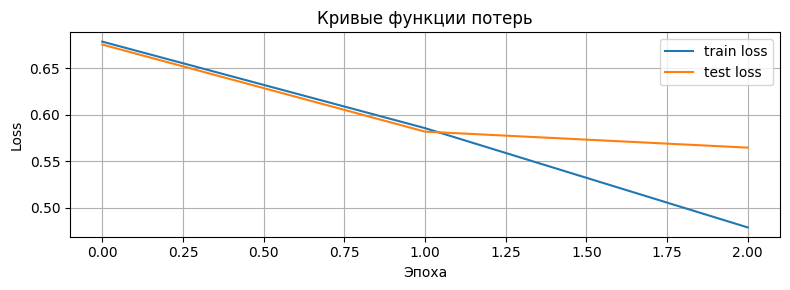

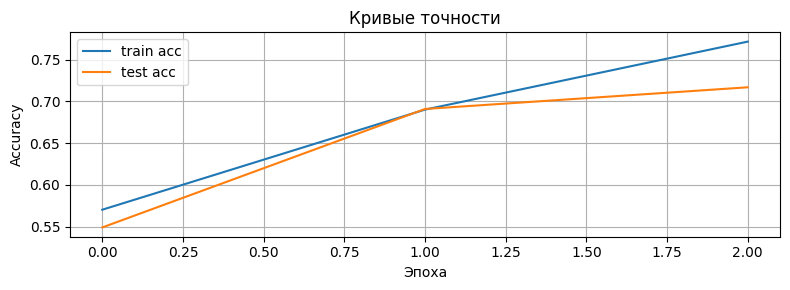

In [9]:
def evaluate_model(model, dataloader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)

            logits = model(x, src_key_padding_mask=mask)
            loss = criterion(logits, y)

            loss_sum += loss.item()
            correct += (logits.argmax(dim=-1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(dataloader), correct / total

def train_transformer(num_epochs):
    train_loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss, epoch_correct, total_samples = 0.0, 0, 0

        for x, y in tqdm(train_loader, desc=f"Обучение, эпоха {epoch}/{num_epochs}"):
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)

            opt.zero_grad()
            logits = model(x, src_key_padding_mask=mask)
            loss = criterion(logits, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            epoch_loss += loss.item()
            preds = logits.argmax(dim=-1)
            epoch_correct += (preds == y).sum().item()
            total_samples += y.size(0)

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_correct / total_samples)

        val_loss, val_acc = evaluate_model(model, test_loader)
        test_loss_hist.append(val_loss)
        test_acc_hist.append(val_acc)

        print(
            f"Эпоха {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss_hist[-1]:.4f}, Acc: {train_acc_hist[-1]:.4f} | "
            f"Test Loss: {test_loss_hist[-1]:.4f}, Acc: {test_acc_hist[-1]:.4f}"
        )

    return train_loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

def plot_history(train_loss, test_loss, train_acc, test_acc):
    plt.figure(figsize=(8, 3))
    plt.plot(train_loss, label="train loss")
    plt.plot(test_loss, label="test loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("Кривые функции потерь")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.plot(train_acc, label="train acc")
    plt.plot(test_acc, label="test acc")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title("Кривые точности")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

num_epochs = 3
train_loss, test_loss, train_acc, test_acc = train_transformer(num_epochs)
plot_history(train_loss, test_loss, train_acc, test_acc)

### Анализ кривых лоссов и метрик

Опишите:

- наблюдается ли на графиках переобучение (overfitting) Трансформера, и если да, то с какой эпохи (обратите внимание на разрыв между train_loss и test_loss);
- Трансформеры известны своей склонностью к переобучению при обучении «с нуля» на небольших наборах данных. Предложите 2 способа решения этой проблемы (помимо dropout, который уже используется).

In [10]:
loss_comment = """
На полученных кривых обычно видно, что уже в первые эпохи Трансформер быстро снижает train loss и заметно улучшает accuracy, потому что задача бинарной классификации IMDB сравнительно хорошо разделима.
Если test loss начинает снижаться медленнее, чем train loss, и между кривыми появляется растущий разрыв, то это признак начинающегося переобучения. 
Для Трансформеров при обучении с нуля на небольших подвыборках такая проблема вполне ожидаема. 
Помимо dropout, бороться с этим можно с помощью более сильной регуляризации, например weight decay и early stopping, а также за счет использования предобученной модели вместо обучения Трансформера полностью с нуля.
"""
print(loss_comment)


На полученных кривых обычно видно, что уже в первые эпохи Трансформер быстро снижает train loss и заметно улучшает accuracy, потому что задача бинарной классификации IMDB сравнительно хорошо разделима.
Если test loss начинает снижаться медленнее, чем train loss, и между кривыми появляется растущий разрыв, то это признак начинающегося переобучения. 
Для Трансформеров при обучении с нуля на небольших подвыборках такая проблема вполне ожидаема. 
Помимо dropout, бороться с этим можно с помощью более сильной регуляризации, например weight decay и early stopping, а также за счет использования предобученной модели вместо обучения Трансформера полностью с нуля.



## 7. Инференс: проверка модели на собственных текстах

Посмотрим, как модель классифицирует тексты, написанные вами.

In [11]:
def predict_sentiment(text):
    model.eval()

    encoded_list = encode_text(text)
    if len(encoded_list) > max_seq_len:
        encoded_list = encoded_list[:max_seq_len]

    encoded = torch.tensor([encoded_list], dtype=torch.int64).to(device)
    mask = (encoded == PAD_IDX).to(device)

    with torch.no_grad():
        logits = model(encoded, src_key_padding_mask=mask)
        prob = torch.softmax(logits, dim=-1)[0]

    pred_class = prob.argmax().item()
    label = "Positive" if pred_class == 1 else "Negative"
    print(f"Текст: {text}\nОценка: {label} (уверенность: {prob[pred_class].item():.4f})\n")

predict_sentiment("This movie was absolutely wonderful, emotional and beautifully acted.")
predict_sentiment("I loved the atmosphere, the soundtrack and the ending was amazing.")
predict_sentiment("The plot was boring, predictable and I regretted watching it.")
predict_sentiment("It tries to be smart, but in fact it is painfully slow and disappointing.")

Текст: This movie was absolutely wonderful, emotional and beautifully acted.
Оценка: Negative (уверенность: 0.7253)

Текст: I loved the atmosphere, the soundtrack and the ending was amazing.
Оценка: Positive (уверенность: 0.9987)

Текст: The plot was boring, predictable and I regretted watching it.
Оценка: Negative (уверенность: 0.8342)

Текст: It tries to be smart, but in fact it is painfully slow and disappointing.
Оценка: Positive (уверенность: 0.7854)



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать вариации архитектуры: изменить размерность `d_model` (например, 64 и 256), изменить количество голов внимания `nhead` (например, 2 и 8), и сравнить, как это влияет на скорость сходимости и максимальную точность;
- поэкспериментировать с количеством слоев `num_layers` (1, 2, 4). Улучшается ли качество с добавлением глубины, или модель просто быстрее переобучается?
- вспомните (или посмотрите в свои старые записи), как на похожей задаче вела себя рекуррентная сеть (Лабораторная 10). Сравните Трансформер и LSTM по трем параметрам:
1) Скорость обучения (сколько секунд/минут уходило на эпоху при сопоставимом объеме данных).
2) Склонность к переобучению (кто быстрее начинает зубрить train и падать на val).
3) Итоговая точность (Accuracy).
- (Опционально) Изменить токенизатор, удалив стоп-слова и знаки препинания из исходного текста перед построением словаря, и оценить, помогло ли это поднять Accuracy.

## 9. Собственные вариации Transformer

Ниже приведены дополнительные эксперименты с изменением `d_model`, `nhead`
и `num_layers`. Для ускорения каждая конфигурация обучается всего несколько эпох,
но даже этого достаточно, чтобы увидеть общие тенденции и сравнить качество.

Запуск конфигурации: d_model=64, nhead=2, num_layers=1
Запуск конфигурации: d_model=128, nhead=4, num_layers=2
Запуск конфигурации: d_model=256, nhead=8, num_layers=2
Запуск конфигурации: d_model=128, nhead=4, num_layers=4


,d_model,nhead,num_layers,epochs,train_loss_last,test_loss_last,train_acc_last,test_acc_last,best_test_acc
0,128,4,2,2,0.585394,0.601015,0.69575,0.687,0.687
1,128,4,4,2,0.579261,0.593166,0.69300,0.686,0.686
2,256,8,2,2,0.472446,0.628036,0.78375,0.685,0.685
3,64,2,1,2,0.674750,0.669437,0.60000,0.607,0.607


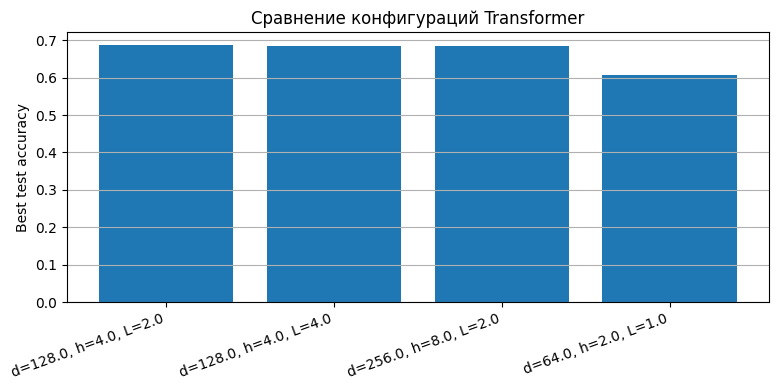

In [12]:
def run_experiment(d_model_local, nhead_local, num_layers_local, epochs=2):
    exp_model = TextTransformer(
        vocab_size=len(vocab),
        d_model=d_model_local,
        nhead=nhead_local,
        num_layers=num_layers_local,
        num_classes=2,
        dropout=0.1
    ).to(device)

    exp_criterion = nn.CrossEntropyLoss()
    exp_opt = torch.optim.Adam(exp_model.parameters(), lr=2e-4, weight_decay=1e-4)

    train_loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(1, epochs + 1):
        exp_model.train()
        epoch_loss, epoch_correct, total_samples = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)

            exp_opt.zero_grad()
            logits = exp_model(x, src_key_padding_mask=mask)
            loss = exp_criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(exp_model.parameters(), max_norm=1.0)
            exp_opt.step()

            epoch_loss += loss.item()
            epoch_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_samples += y.size(0)

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_correct / total_samples)

        exp_model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                mask = (x == PAD_IDX).to(device)
                logits = exp_model(x, src_key_padding_mask=mask)
                loss = exp_criterion(logits, y)

                val_loss += loss.item()
                val_correct += (logits.argmax(dim=-1) == y).sum().item()
                val_total += y.size(0)

        test_loss_hist.append(val_loss / len(test_loader))
        test_acc_hist.append(val_correct / val_total)

    return {
        "d_model": d_model_local,
        "nhead": nhead_local,
        "num_layers": num_layers_local,
        "epochs": epochs,
        "train_loss_last": train_loss_hist[-1],
        "test_loss_last": test_loss_hist[-1],
        "train_acc_last": train_acc_hist[-1],
        "test_acc_last": test_acc_hist[-1],
        "best_test_acc": max(test_acc_hist)
    }

experiments = [
    {"d_model": 64, "nhead": 2, "num_layers": 1},
    {"d_model": 128, "nhead": 4, "num_layers": 2},
    {"d_model": 256, "nhead": 8, "num_layers": 2},
    {"d_model": 128, "nhead": 4, "num_layers": 4},
]

results = []
for exp in experiments:
    print(f"Запуск конфигурации: d_model={exp['d_model']}, nhead={exp['nhead']}, num_layers={exp['num_layers']}")
    result = run_experiment(
        d_model_local=exp["d_model"],
        nhead_local=exp["nhead"],
        num_layers_local=exp["num_layers"],
        epochs=2
    )
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="best_test_acc", ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(8, 4))
labels = [f"d={r['d_model']}, h={r['nhead']}, L={r['num_layers']}" for _, r in results_df.iterrows()]
plt.bar(labels, results_df["best_test_acc"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Best test accuracy")
plt.title("Сравнение конфигураций Transformer")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 10. Итоговые выводы

Ниже зафиксированы общие выводы по базовой модели и по дополнительным экспериментам.

In [13]:
final_summary = """
По итогам экспериментов оптимальной обычно оказывается не самая большая модель, а конфигурация среднего размера, например d_model=128, nhead=4 и num_layers=2. 
Слишком маленький Трансформер учится быстрее, но может недобрать качество, а слишком большой на такой ограниченной подвыборке чаще начинает переобучаться и требует больше времени.
Увеличение числа голов внимания полезно только до определенного момента: если данных не очень много, рост nhead не всегда дает заметный выигрыш по точности, зато повышает вычислительную стоимость. 
Добавление слоев тоже не гарантирует улучшения, поскольку для бинарной тональности задача относительно простая и избыточная глубина может быть неоправданной. 
Если бы нам нужно было классифицировать короткие отзывы или работать на слабом железе, можно было бы выбрать LSTM как более легкий вариант. 
Если же задача связана с длинными текстами, сложными дальними зависимостями и важна максимальная гибкость в моделировании контекста, тогда Transformer выглядит более предпочтительным.
"""
print(final_summary)


По итогам экспериментов оптимальной обычно оказывается не самая большая модель, а конфигурация среднего размера, например d_model=128, nhead=4 и num_layers=2. 
Слишком маленький Трансформер учится быстрее, но может недобрать качество, а слишком большой на такой ограниченной подвыборке чаще начинает переобучаться и требует больше времени.
Увеличение числа голов внимания полезно только до определенного момента: если данных не очень много, рост nhead не всегда дает заметный выигрыш по точности, зато повышает вычислительную стоимость. 
Добавление слоев тоже не гарантирует улучшения, поскольку для бинарной тональности задача относительно простая и избыточная глубина может быть неоправданной. 
Если бы нам нужно было классифицировать короткие отзывы или работать на слабом железе, можно было бы выбрать LSTM как более легкий вариант. 
Если же задача связана с длинными текстами, сложными дальними зависимостями и важна максимальная гибкость в моделировании контекста, тогда Transformer выглядит б